In [28]:
import pandas as pd

DTM_RE_TFIDF_URL = "https://github.com/Magallanes-at-UTDT/texts/raw/main/data/processed/DocumentTermMatrix_Regex_TFIDF.parquet"
dtm_re_tfidf = pd.read_parquet(DTM_RE_TFIDF_URL)
dtm_re_tfidf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, AhoraNacion to RenovacionPopular
Columns: 7825 entries, 0e5 to útil
dtypes: float64(7825)
memory usage: 366.8+ KB


In [29]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(dtm_re_tfidf)

In [30]:
party_similarity = pd.DataFrame(
    similarity_matrix,
    index=dtm_re_tfidf.index,
    columns=dtm_re_tfidf.index
)

party_similarity

,AhoraNacion,BuenGobierno,FuerzaPopular,JuntosPorElPeru,Obras,RenovacionPopular
AhoraNacion,1.000000,0.726668,0.723794,0.739323,0.657853,0.610159
BuenGobierno,0.726668,1.000000,0.643571,0.653122,0.557252,0.534626
FuerzaPopular,0.723794,0.643571,1.000000,0.718229,0.554139,0.535639
JuntosPorElPeru,0.739323,0.653122,0.718229,1.000000,0.621949,0.603355
Obras,0.657853,0.557252,0.554139,0.621949,1.000000,0.541257
RenovacionPopular,0.610159,0.534626,0.535639,0.603355,0.541257,1.000000


In [31]:
import numpy as np

party_similarity_no_self = party_similarity.copy()

np.fill_diagonal(
    party_similarity_no_self.values,
    np.nan
)
most_similar_party = pd.DataFrame({
    "most_similar_party": party_similarity_no_self.idxmax(axis=1),
    "cosine_similarity": party_similarity_no_self.max(axis=1)
})

most_similar_party

,most_similar_party,cosine_similarity
AhoraNacion,JuntosPorElPeru,0.739323
BuenGobierno,AhoraNacion,0.726668
FuerzaPopular,AhoraNacion,0.723794
JuntosPorElPeru,AhoraNacion,0.739323
Obras,AhoraNacion,0.657853
RenovacionPopular,AhoraNacion,0.610159


In [41]:
party_network = nx.Graph()

# Add every party as a node
party_network.add_nodes_from(party_similarity.index)

threshold = 0.65

for i in party_similarity.index:
    for j in party_similarity.columns:

        if i >= j:
            continue

        weight = party_similarity.loc[i, j]

        if weight >= threshold:
            party_network.add_edge(
                i,
                j,
                weight=weight
            )

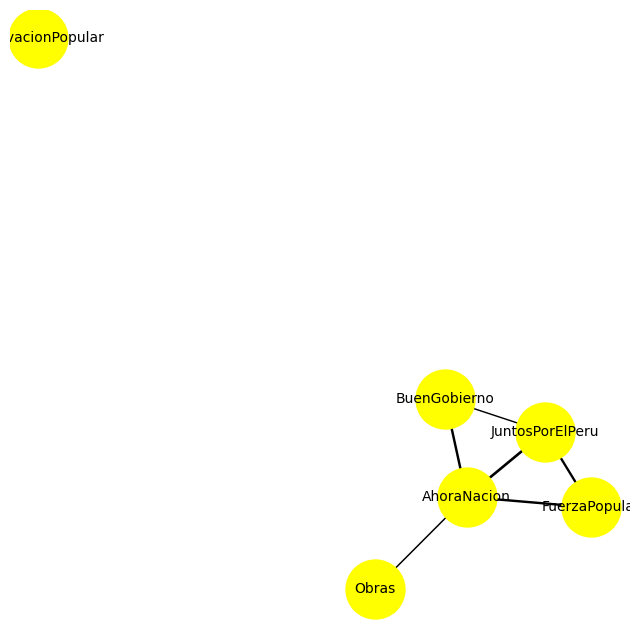

In [48]:
pos = nx.spring_layout(
    party_network,
    seed=123,
    weight="weight"
)

weights = [
    1 + 10*(d["weight"] - threshold)
    for _, _, d in party_network.edges(data=True)
]

plt.figure(figsize=(8,8))

nx.draw_networkx_nodes(
    party_network,
    pos,
    node_color='yellow',
    node_size=1800
)

nx.draw_networkx_labels(
    party_network,
    pos,
    font_size=10
)

nx.draw_networkx_edges(
    party_network,
    pos,
    width=weights
)

plt.axis("off")
plt.show()

In [53]:
import pandas as pd

dtm_regex_URL = "https://github.com/Magallanes-at-UTDT/texts/raw/main/data/processed/DocumentTermMatrix_Regex_Counts.parquet"

dtm_regex = pd.read_parquet(dtm_regex_URL)

In [54]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=123
)

lda.fit(dtm_regex)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [55]:
n_words = 10

for topic_idx, topic in enumerate(lda.components_):
    top_words = (
        pd.Series(topic, index=dtm_regex.columns)
        .sort_values(ascending=False)
        .head(n_words)
        .index
        .tolist()
    )

    print(f"Topic {topic_idx + 1}:")
    print(", ".join(top_words))
    print()

Topic 1:
foco, basada, importar, riguroso, efectivamente, conforme, estandarizado, atendido, viable, convocatoria

Topic 2:
nacional, público, programa, sistema, 2023, perú, 2024, implementación, acceso, servicio

Topic 3:
nacional, meta, desarrollo, porcentaje, sistema, público, país, problema, servicio, estratégico

Topic 4:
objetivo, nacional, 2031, sistema, estratégico, público, desarrollo, fortalecer, regional, indicador

Topic 5:
nacional, salud, público, gobierno, 2026, desarrollo, plan, sistema, país, social



In [56]:
topic_distribution = lda.transform(dtm_regex)

party_topics = pd.DataFrame(
    topic_distribution,
    index=dtm_regex.index,
    columns=[f"Topic_{i+1}" for i in range(n_topics)]
)

party_topics

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
AhoraNacion,0.000007,0.000007,0.999971,0.000007,0.000007
BuenGobierno,0.000012,0.000012,0.000013,0.999950,0.000012
FuerzaPopular,0.000008,0.991975,0.008001,0.000008,0.000008
JuntosPorElPeru,0.000013,0.000013,0.000013,0.000013,0.999947
Obras,0.000067,0.000069,0.135625,0.000069,0.864170
RenovacionPopular,0.000055,0.000056,0.000056,0.000056,0.999776
